#### Setup and Data Download
The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install pystac-client odc-stac rioxarray dask['distributed'] \
      jupyter-server-proxy planetary_computer

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
import planetary_computer as pc
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
from odc import stac
import geopandas as gpd

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [ ]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

data_url = 'https://storage.googleapis.com/spatialthoughts-public-data/python-remote-sensing/'

aoi = 'bangalore.geojson'
download(data_url + aoi)

#### Get Satellite Imagery using STAC API

We define a location and time of interest to get some satellite imagery.

In [ ]:
aoi_path = os.path.join(data_folder, aoi)
city_gdf = gpd.read_file(aoi_path)
geometry = city_gdf.geometry
bbox = geometry.total_bounds
bbox

Let's use [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/) search endpoint to look for items from the sentinel-2-l2a collection on Azure Blob Storage.

In [ ]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1')

search = catalog.search(
    collections=['landsat-c2-l2'],
    bbox=bbox,
    datetime=f'{year}',
    query={
        'eo:cloud_cover': {'lt': 30},
        'platform': {'eq': 'landsat-8'},
    })
items = search.item_collection()
items

Load the matching images as a XArray Dataset. Accessing data from Planetary Computer is free but requires getting a Shared Access Signature (SAS) token and sign the URLs. The `planetary_computer` Python package provides a simple mechanism for signing the URLs using `sign()` function.

In [ ]:
# Load to XArray
ds = stac.load(
    items,
    bands=['red', 'green', 'blue'],
    bbox=bbox, # <-- load data only for the bbox
    resolution=30,
    crs='utm',
    chunks={},  # <-- use Dask
    patch_url=pc.sign,
    groupby='solar_day',
    preserve_original_order=True
)
ds

#### Processing Data

Apply scale and offset to all spectral bands

In [48]:
for band in ['red', 'green', 'blue']:
  print(items[0].assets[band].extra_fields['raster:bands'][0])

{'scale': 2.75e-05, 'nodata': 0, 'offset': -0.2, 'data_type': 'uint16', 'spatial_resolution': 30}
{'scale': 2.75e-05, 'nodata': 0, 'offset': -0.2, 'data_type': 'uint16', 'spatial_resolution': 30}
{'scale': 2.75e-05, 'nodata': 0, 'offset': -0.2, 'data_type': 'uint16', 'spatial_resolution': 30}


In [ ]:
# Apply scale/offset
scale = 2.75e-05
offset = -0.2
# Select spectral bands (all except 'scl')
data_bands = [band for band in ds.data_vars if band != 'SCL']
for band in data_bands:
  ds[band] = ds[band] * scale + offset

Convert to DataArray

In [ ]:
da = ds.to_array('band')
da

Create a Median Composite

In [ ]:
rgb_composite = da \
  .sel(band=['red', 'green', 'blue']) \
  .median(dim='time')
rgb_composite

In [ ]:
%%time
rgb_composite = rgb_composite.compute()

### Visualizing Results

In [ ]:
image_crs = rgb_composite.rio.crs
city_gdf_reprojected = city_gdf.to_crs(image_crs)
rgb_composite_clipped = rgb_composite.rio.clip(city_gdf_reprojected.geometry)

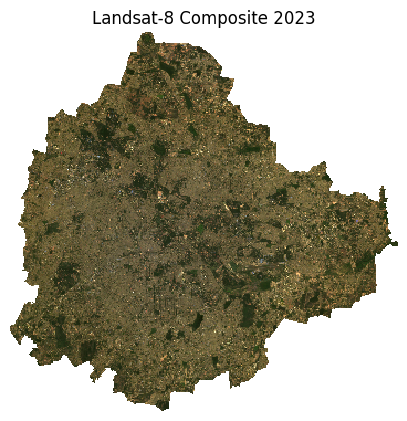

In [50]:
preview = rgb_composite_clipped.rio.reproject(
    rgb_composite_clipped.rio.crs, resolution=100
)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    vmin=0, vmax=0.3)
ax.set_title(f'Landsat-8 Composite {year}')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()